# Case Técnico — Cientista de Dados Júnior — Datarisk

## 1. Introdução

O case propõe estimar o risco de atraso em cobranças mensais a partir do histórico de pagamentos, das características cadastrais e das informações mensais dos clientes. A unidade de previsão é **uma cobrança**, representada por uma linha da base de pagamentos.

Considera-se inadimplente a cobrança paga **cinco dias ou mais após a data de vencimento**. A saída esperada é a probabilidade desse evento, em um valor contínuo entre 0 e 1, e não uma classificação binária.

A solução percorre as seguintes etapas: leitura e validação das bases, construção da variável-alvo, consolidação das informações, análise exploratória, preparação das features, validação dos modelos e geração das probabilidades para a base de teste. As decisões e limitações são registradas junto aos resultados correspondentes.

## 2. Imports e configurações

Esta seção concentra as dependências e configurações compartilhadas pelo notebook. Um único caminho, `DATA_DIR`, referencia a pasta com os quatro arquivos fornecidos.

In [1]:
from pathlib import Path

# Manipulação e análise de dados
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações gerais
DATA_DIR = Path("data")
RANDOM_STATE = 0

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

assert DATA_DIR.is_dir(), f"Pasta de dados não encontrada: {DATA_DIR.resolve()}"
print(f"Diretório de dados: {DATA_DIR.resolve()}")

Diretório de dados: C:\Users\ricar\OneDrive\Área de Trabalho\case_datarisk\data


As bibliotecas utilizadas nas seções seguintes foram carregadas e o diretório de dados foi localizado. Não é necessário um arquivo externo de configuração para esta estrutura.

## 3. Leitura e inspeção inicial das bases

Os arquivos são lidos com separador `;`. `DDD` e `CEP_2_DIG` são tratados como texto, pois funcionam como categorias. Antes de qualquer junção, `_ROW_ID` registra a posição original de cada cobrança da base de teste.

In [2]:
base_cadastral = pd.read_csv(
    DATA_DIR / "base_cadastral.csv",
    sep=";",
    dtype={"DDD": "string", "CEP_2_DIG": "string"},
)
base_info = pd.read_csv(DATA_DIR / "base_info.csv", sep=";")
base_dev = pd.read_csv(DATA_DIR / "base_pagamentos_desenvolvimento.csv", sep=";")
base_test = pd.read_csv(DATA_DIR / "base_pagamentos_teste.csv", sep=";")

# Identificador técnico mantido até a submissão para preservar a ordem original.
base_test["_ROW_ID"] = np.arange(len(base_test))

assert base_test["_ROW_ID"].is_unique

bases = {
    "base_cadastral": base_cadastral,
    "base_info": base_info,
    "base_pagamentos_desenvolvimento": base_dev,
    "base_pagamentos_teste": base_test,
}

chaves_esperadas = {
    "base_cadastral": "ID_CLIENTE",
    "base_info": "ID_CLIENTE + SAFRA_REF",
    "base_pagamentos_desenvolvimento": "uma cobrança",
    "base_pagamentos_teste": "uma cobrança",
}

resumo_bases = pd.DataFrame(
    [
        {
            "base": nome,
            "linhas": len(df),
            "colunas": df.shape[1] - (1 if nome == "base_pagamentos_teste" else 0),
            "chave_esperada": chaves_esperadas[nome],
        }
        for nome, df in bases.items()
    ]
)
resumo_bases

,base,linhas,colunas,chave_esperada
0,base_cadastral,1315,8,ID_CLIENTE
1,base_info,24401,4,ID_CLIENTE + SAFRA_REF
2,base_pagamentos_desenvolvimento,77414,7,uma cobrança
3,base_pagamentos_teste,12275,6,uma cobrança


A tabela consolida o tamanho e a granularidade esperada de cada fonte. A coluna técnica `_ROW_ID` não é contabilizada entre as colunas originais da base de teste.

In [3]:
inspecao_inicial = pd.concat(
    [
        pd.DataFrame(
            {
                "base": nome,
                "coluna": df.columns,
                "tipo_original": df.dtypes.astype(str).to_numpy(),
                "ausentes": df.isna().sum().to_numpy(),
                "proporcao_ausente": df.isna().mean().to_numpy(),
            }
        )
        for nome, df in bases.items()
    ],
    ignore_index=True,
)

inspecao_inicial

,base,coluna,tipo_original,ausentes,proporcao_ausente
0,base_cadastral,ID_CLIENTE,int64,0,0.000000
1,base_cadastral,DATA_CADASTRO,str,0,0.000000
2,base_cadastral,DDD,string,237,0.180228
3,base_cadastral,FLAG_PF,str,1249,0.949810
4,base_cadastral,SEGMENTO_INDUSTRIAL,str,83,0.063118
5,base_cadastral,DOMINIO_EMAIL,str,30,0.022814
6,base_cadastral,PORTE,str,41,0.031179
7,base_cadastral,CEP_2_DIG,string,0,0.000000
8,base_info,ID_CLIENTE,int64,0,0.000000
9,base_info,SAFRA_REF,str,0,0.000000


A inspeção por coluna substitui sequências de `head()` sem objetivo analítico. Ela permite identificar tipos importados e ausências antes de qualquer tratamento. Neste momento, valores ausentes são apenas quantificados; sua origem não é inferida automaticamente.

## 4. Conversão de tipos, datas e safras

As datas são convertidas com `errors="coerce"` para que valores inválidos sejam expostos como `NaT`. `SAFRA_REF` é preservada e uma nova coluna `SAFRA_DT` representa o primeiro dia do mês de referência.

In [4]:
colunas_data = {
    "base_cadastral": ["DATA_CADASTRO"],
    "base_pagamentos_desenvolvimento": [
        "DATA_EMISSAO_DOCUMENTO",
        "DATA_PAGAMENTO",
        "DATA_VENCIMENTO",
    ],
    "base_pagamentos_teste": [
        "DATA_EMISSAO_DOCUMENTO",
        "DATA_VENCIMENTO",
    ],
}

relatorio_conversao = []

for nome, colunas in colunas_data.items():
    df = bases[nome]
    for coluna in colunas:
        ausentes_antes = df[coluna].isna().sum()
        df[coluna] = pd.to_datetime(df[coluna], errors="coerce")
        ausentes_depois = df[coluna].isna().sum()
        relatorio_conversao.append(
            {
                "base": nome,
                "coluna": coluna,
                "NaT_total": int(ausentes_depois),
                "novos_NaT_na_conversao": int(ausentes_depois - ausentes_antes),
            }
        )

for nome in [
    "base_info",
    "base_pagamentos_desenvolvimento",
    "base_pagamentos_teste",
]:
    df = bases[nome]
    safra_original = df["SAFRA_REF"].copy()
    df["SAFRA_DT"] = pd.to_datetime(
        df["SAFRA_REF"],
        format="%Y-%m",
        errors="coerce",
    )
    assert df["SAFRA_REF"].equals(safra_original)
    relatorio_conversao.append(
        {
            "base": nome,
            "coluna": "SAFRA_DT",
            "NaT_total": int(df["SAFRA_DT"].isna().sum()),
            "novos_NaT_na_conversao": int(
                (df["SAFRA_DT"].isna() & df["SAFRA_REF"].notna()).sum()
            ),
        }
    )

relatorio_conversao = pd.DataFrame(relatorio_conversao)
relatorio_conversao

,base,coluna,NaT_total,novos_NaT_na_conversao
0,base_cadastral,DATA_CADASTRO,0,0
1,base_pagamentos_desenvolvimento,DATA_EMISSAO_DOCUMENTO,0,0
2,base_pagamentos_desenvolvimento,DATA_PAGAMENTO,0,0
3,base_pagamentos_desenvolvimento,DATA_VENCIMENTO,0,0
4,base_pagamentos_teste,DATA_EMISSAO_DOCUMENTO,0,0
5,base_pagamentos_teste,DATA_VENCIMENTO,0,0
6,base_info,SAFRA_DT,0,0
7,base_pagamentos_desenvolvimento,SAFRA_DT,0,0
8,base_pagamentos_teste,SAFRA_DT,0,0


In [5]:
periodos = pd.DataFrame(
    {
        "base": ["desenvolvimento", "teste"],
        "periodo_minimo": [
            base_dev["SAFRA_DT"].min(),
            base_test["SAFRA_DT"].min(),
        ],
        "periodo_maximo": [
            base_dev["SAFRA_DT"].max(),
            base_test["SAFRA_DT"].max(),
        ],
    }
)
periodos

,base,periodo_minimo,periodo_maximo
0,desenvolvimento,2018-08-01,2021-06-01
1,teste,2021-07-01,2021-11-01


As conversões não produziram novos `NaT`. O desenvolvimento abrange agosto de 2018 a junho de 2021, enquanto o teste contém cobranças de julho a novembro de 2021. A posição temporal do teste deve ser considerada posteriormente na estratégia de validação.

## 5. Construção da variável-alvo

Antes do cálculo, são verificadas as datas essenciais e inconsistências cronológicas. Uma cobrança sem pagamento ou vencimento não pode receber silenciosamente `TARGET = 0`; caso exista, a execução é interrompida para exigir uma decisão explícita.

Pagamentos ou vencimentos anteriores à emissão são reportados, mas não corrigidos nem removidos, pois o dicionário não fornece uma regra para esses casos. O target continua seguindo estritamente a diferença entre pagamento e vencimento.

In [6]:
qualidade_datas_target = pd.Series(
    {
        "DATA_PAGAMENTO ausente": base_dev["DATA_PAGAMENTO"].isna().sum(),
        "DATA_VENCIMENTO ausente": base_dev["DATA_VENCIMENTO"].isna().sum(),
        "pagamento anterior à emissão": (
            base_dev["DATA_PAGAMENTO"] < base_dev["DATA_EMISSAO_DOCUMENTO"]
        ).sum(),
        "vencimento anterior à emissão": (
            base_dev["DATA_VENCIMENTO"] < base_dev["DATA_EMISSAO_DOCUMENTO"]
        ).sum(),
    },
    name="quantidade",
).astype(int)

qualidade_datas_target

DATA_PAGAMENTO ausente            0
DATA_VENCIMENTO ausente           0
pagamento anterior à emissão     26
vencimento anterior à emissão    27
Name: quantidade, dtype: int64

In [7]:
campos_essenciais_ausentes = (
    qualidade_datas_target["DATA_PAGAMENTO ausente"]
    + qualidade_datas_target["DATA_VENCIMENTO ausente"]
)

if campos_essenciais_ausentes > 0:
    raise ValueError(
        "Existem cobranças sem DATA_PAGAMENTO ou DATA_VENCIMENTO; "
        "o TARGET não será criado até que o tratamento seja definido."
    )

base_dev["DIAS_ATRASO"] = (
    base_dev["DATA_PAGAMENTO"] - base_dev["DATA_VENCIMENTO"]
).dt.days
base_dev["TARGET"] = (base_dev["DIAS_ATRASO"] >= 5).astype("int8")

assert set(base_dev["TARGET"].unique()).issubset({0, 1})
assert base_dev["TARGET"].notna().all()

In [8]:
casos_limite_target = pd.DataFrame(
    {
        "DIAS_ATRASO": [4, 5, 6],
        "TARGET_ESPERADO": [0, 1, 1],
    }
)
casos_limite_target["TARGET_CALCULADO"] = (
    casos_limite_target["DIAS_ATRASO"] >= 5
).astype(int)

assert casos_limite_target["TARGET_CALCULADO"].equals(
    casos_limite_target["TARGET_ESPERADO"]
)
casos_limite_target

,DIAS_ATRASO,TARGET_ESPERADO,TARGET_CALCULADO
0,4,0,0
1,5,1,1
2,6,1,1


In [9]:
distribuicao_target = (
    base_dev["TARGET"]
    .value_counts()
    .sort_index()
    .rename_axis("TARGET")
    .to_frame("quantidade")
    .assign(proporcao=lambda x: x["quantidade"] / x["quantidade"].sum())
)
distribuicao_target

,quantidade,proporcao
TARGET,,
0,71978,0.92978
1,5436,0.07022


Não há pagamentos ou vencimentos ausentes no desenvolvimento. Foram identificados 26 pagamentos e 27 vencimentos anteriores à emissão; as linhas foram mantidas e a inconsistência fica registrada como limitação de qualidade. Os testes de fronteira confirmam a regra: quatro dias recebe 0, enquanto cinco e seis dias recebem 1.

## 6. Consolidação e validação dos merges

A base de pagamentos define a quantidade e a ordem das linhas. Cadastro é incorporado por `ID_CLIENTE`, e informações mensais por `ID_CLIENTE` e `SAFRA_REF`, sempre com `left join`. Antes das junções, a unicidade das chaves dimensionais é validada.

In [10]:
duplicados_cadastral = base_cadastral.duplicated(["ID_CLIENTE"]).sum()
duplicados_info = base_info.duplicated(["ID_CLIENTE", "SAFRA_REF"]).sum()

assert duplicados_cadastral == 0, "ID_CLIENTE não é único na base cadastral."
assert duplicados_info == 0, "ID_CLIENTE + SAFRA_REF não é único na base_info."

pd.Series(
    {
        "ID_CLIENTE duplicado na cadastral": duplicados_cadastral,
        "ID_CLIENTE + SAFRA_REF duplicado na info": duplicados_info,
    },
    name="quantidade",
)

ID_CLIENTE duplicado na cadastral           0
ID_CLIENTE + SAFRA_REF duplicado na info    0
Name: quantidade, dtype: int64

In [11]:
def consolidar_pagamentos(pagamentos, nome_base):
    linhas_antes = len(pagamentos)

    consolidada = pagamentos.merge(
        base_cadastral,
        on="ID_CLIENTE",
        how="left",
        sort=False,
        validate="many_to_one",
        indicator="_MATCH_CADASTRO",
    )
    cobertura_cadastro = consolidada["_MATCH_CADASTRO"].eq("both").mean()
    consolidada = consolidada.drop(columns="_MATCH_CADASTRO")

    # SAFRA_DT já existe em pagamentos; a informação mensal é ligada pela
    # chave original para evitar colunas temporais duplicadas.
    info_para_merge = base_info.drop(columns="SAFRA_DT")
    consolidada = consolidada.merge(
        info_para_merge,
        on=["ID_CLIENTE", "SAFRA_REF"],
        how="left",
        sort=False,
        validate="many_to_one",
        indicator="_MATCH_INFO",
    )
    cobertura_info = consolidada["_MATCH_INFO"].eq("both").mean()
    consolidada = consolidada.drop(columns="_MATCH_INFO")

    assert len(consolidada) == linhas_antes

    diagnostico = {
        "base": nome_base,
        "linhas_antes": linhas_antes,
        "linhas_depois": len(consolidada),
        "cobertura_cadastro": cobertura_cadastro,
        "cobertura_info": cobertura_info,
        "linhas_sem_cadastro": int(round((1 - cobertura_cadastro) * linhas_antes)),
        "linhas_sem_info": int(round((1 - cobertura_info) * linhas_antes)),
    }
    return consolidada, diagnostico


dev_full, diagnostico_dev = consolidar_pagamentos(base_dev, "desenvolvimento")
test_full, diagnostico_test = consolidar_pagamentos(base_test, "teste")

cobertura_merges = pd.DataFrame([diagnostico_dev, diagnostico_test])
cobertura_merges

,base,linhas_antes,linhas_depois,cobertura_cadastro,cobertura_info,linhas_sem_cadastro,linhas_sem_info
0,desenvolvimento,77414,77414,1.000000,0.949144,0,3937
1,teste,12275,12275,0.996904,0.966273,38,414


In [12]:
assert len(dev_full) == len(base_dev)
assert len(test_full) == len(base_test)
assert dev_full.shape[0] <= base_dev.shape[0]
assert test_full.shape[0] <= base_test.shape[0]
assert test_full["_ROW_ID"].is_unique
assert test_full["_ROW_ID"].tolist() == list(range(len(base_test)))
assert set(dev_full["TARGET"].unique()).issubset({0, 1})

colunas_cadastrais = [
    coluna for coluna in base_cadastral.columns if coluna != "ID_CLIENTE"
]
colunas_info = [
    coluna
    for coluna in base_info.columns
    if coluna not in {"ID_CLIENTE", "SAFRA_REF", "SAFRA_DT"}
]

ausencias_apos_merge = pd.DataFrame(
    {
        "desenvolvimento": dev_full[colunas_cadastrais + colunas_info].isna().sum(),
        "teste": test_full[colunas_cadastrais + colunas_info].isna().sum(),
    }
).sort_values("desenvolvimento", ascending=False)

display(ausencias_apos_merge)

shapes_finais = pd.DataFrame(
    {
        "base": ["desenvolvimento consolidado", "teste consolidado"],
        "linhas": [len(dev_full), len(test_full)],
        "colunas": [dev_full.shape[1], test_full.shape[1]],
    }
)
shapes_finais

,desenvolvimento,teste
FLAG_PF,77195,12228
NO_FUNCIONARIOS,7587,1167
DDD,7414,1377
RENDA_MES_ANTERIOR,6132,726
PORTE,2476,416
SEGMENTO_INDUSTRIAL,1417,254
DOMINIO_EMAIL,898,208
DATA_CADASTRO,0,38
CEP_2_DIG,0,38


,base,linhas,colunas
0,desenvolvimento consolidado,77414,19
1,teste consolidado,12275,17


As duas junções preservam integralmente o número de cobranças e a ordem do teste. A cobertura separa ausência de correspondência no merge de valores originalmente ausentes nas tabelas dimensionais; portanto, valores faltantes não são interpretados sem consultar sua origem e o dicionário.

## 7. Análise Exploratória de Dados (EDA)

A EDA investiga a granularidade das cobranças, a distribuição do target, sua evolução temporal e as características disponíveis para modelagem. A base de teste é usada somente em comparações sem desfecho. Para isolar esta etapa das transformações posteriores, as análises são realizadas em cópias das bases consolidadas.

In [13]:
eda_dev = dev_full.copy()
eda_test = test_full.copy()

# Segundo o dicionário: X representa pessoa física e NaN, pessoa jurídica.
assert set(eda_dev["FLAG_PF"].dropna().unique()).issubset({"X"})
assert set(eda_test["FLAG_PF"].dropna().unique()).issubset({"X"})

eda_dev["TIPO_PESSOA"] = np.where(eda_dev["FLAG_PF"].eq("X"), "PF", "PJ")
eda_test["TIPO_PESSOA"] = np.where(eda_test["FLAG_PF"].eq("X"), "PF", "PJ")

### 7.1. Visão geral e granularidade

A unidade de modelagem é uma cobrança. Um cliente pode possuir várias cobranças na mesma safra e reaparecer em diferentes meses; por isso, quantidade de linhas e quantidade de clientes descrevem granularidades distintas.

In [14]:
clientes_dev = set(eda_dev["ID_CLIENTE"])
clientes_test = set(eda_test["ID_CLIENTE"])
clientes_em_comum = clientes_dev & clientes_test

visao_geral = pd.DataFrame(
    {
        "indicador": [
            "Cobranças no desenvolvimento",
            "Clientes no desenvolvimento",
            "Período do desenvolvimento",
            "Cobranças no teste",
            "Clientes no teste",
            "Período do teste",
            "Clientes do teste presentes no desenvolvimento",
        ],
        "valor": [
            f"{len(eda_dev):,}".replace(",", "."),
            f"{eda_dev['ID_CLIENTE'].nunique():,}".replace(",", "."),
            f"{eda_dev['SAFRA_DT'].min():%Y-%m} a {eda_dev['SAFRA_DT'].max():%Y-%m}",
            f"{len(eda_test):,}".replace(",", "."),
            f"{eda_test['ID_CLIENTE'].nunique():,}".replace(",", "."),
            f"{eda_test['SAFRA_DT'].min():%Y-%m} a {eda_test['SAFRA_DT'].max():%Y-%m}",
            f"{len(clientes_em_comum):,} ({len(clientes_em_comum) / len(clientes_test):.2%})",
        ],
    }
)

cobrancas_por_cliente = eda_dev.groupby("ID_CLIENTE").size()
resumo_cobrancas_cliente = (
    cobrancas_por_cliente.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .rename("cobrancas_por_cliente")
    .to_frame()
)

display(visao_geral)
resumo_cobrancas_cliente

,indicador,valor
0,Cobranças no desenvolvimento,77.414
1,Clientes no desenvolvimento,1.248
2,Período do desenvolvimento,2018-08 a 2021-06
3,Cobranças no teste,12.275
4,Clientes no teste,976
5,Período do teste,2021-07 a 2021-11
6,Clientes do teste presentes no desenvolvimento,888 (90.98%)


,cobrancas_por_cliente
count,1248.000000
mean,62.030449
std,94.393904
min,1.000000
25%,5.000000
50%,28.000000
75%,90.000000
90%,147.300000
95%,212.650000
99%,467.650000


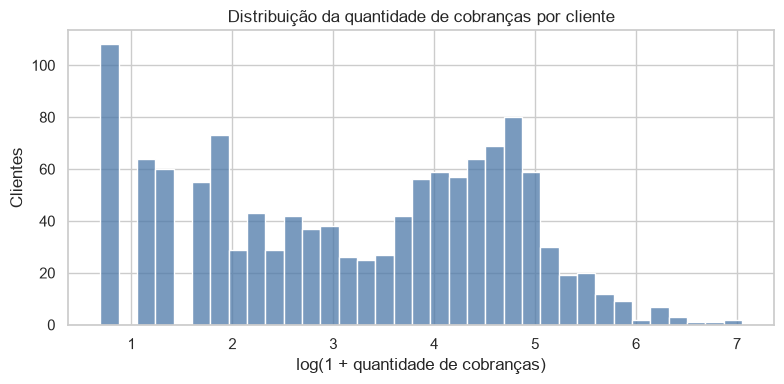

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(np.log1p(cobrancas_por_cliente), bins=35, color="#4C78A8", ax=ax)
ax.set(
    title="Distribuição da quantidade de cobranças por cliente",
    xlabel="log(1 + quantidade de cobranças)",
    ylabel="Clientes",
)
plt.tight_layout()
plt.show()

A mediana é de 28 cobranças por cliente, enquanto 1% dos clientes possui aproximadamente 468 cobranças ou mais. A cauda longa confirma a recorrência e a concentração desigual de registros. Dos 976 clientes do teste, 888 (90,98%) já aparecem no desenvolvimento; a avaliação futura deve considerar essa repetição sem confundir cobrança com cliente.

### 7.2. Distribuição do TARGET

O target indica pagamento com atraso de cinco dias ou mais. Contagem e proporção mostram a frequência do evento na base de desenvolvimento.

In [16]:
distribuicao_target_eda = (
    eda_dev["TARGET"]
    .value_counts()
    .sort_index()
    .rename_axis("TARGET")
    .to_frame("quantidade")
    .assign(percentual=lambda x: 100 * x["quantidade"] / x["quantidade"].sum())
)
distribuicao_target_eda

,quantidade,percentual
TARGET,,
0,71978,92.978014
1,5436,7.021986


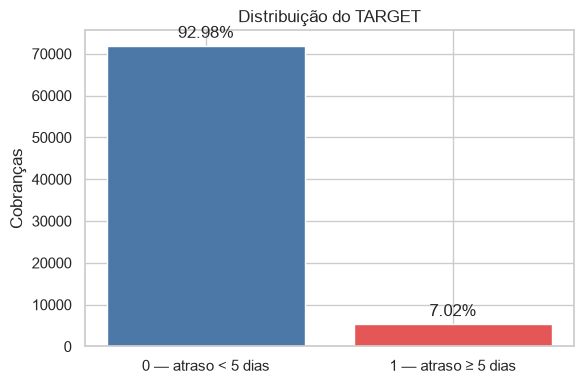

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(
    ["0 — atraso < 5 dias", "1 — atraso ≥ 5 dias"],
    distribuicao_target_eda["quantidade"],
    color=["#4C78A8", "#E45756"],
)
ax.bar_label(
    barras,
    labels=[f"{valor:.2f}%" for valor in distribuicao_target_eda["percentual"]],
    padding=3,
)
ax.set(title="Distribuição do TARGET", ylabel="Cobranças")
plt.tight_layout()
plt.show()

O evento ocorre em 5.436 das 77.414 cobranças (7,02%). Esse desbalanceamento torna pouco informativa uma avaliação baseada apenas em acurácia; métricas voltadas à ordenação e à qualidade das probabilidades deverão ser consideradas posteriormente. A EDA, isoladamente, não torna obrigatório o uso de reamostragem ou pesos de classe.

### 7.3. Evolução temporal

Quantidade de cobranças e taxa do target são agregadas por `SAFRA_DT`. As duas séries ajudam a verificar mudanças de volume e de frequência do evento ao longo do período observado.

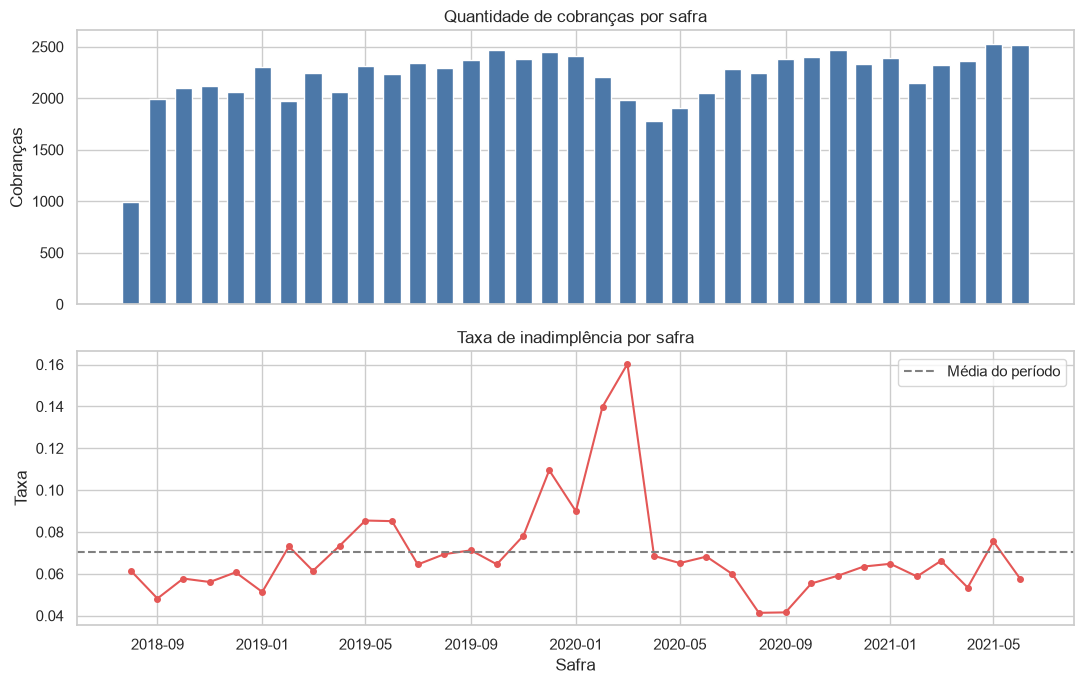

,SAFRA_DT,quantidade_cobrancas,taxa_inadimplencia
19,2020-03-01,1984,0.160282
24,2020-08-01,2249,0.041352


In [18]:
evolucao_mensal = (
    eda_dev.groupby("SAFRA_DT", as_index=False)
    .agg(
        quantidade_cobrancas=("TARGET", "size"),
        taxa_inadimplencia=("TARGET", "mean"),
    )
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].bar(
    evolucao_mensal["SAFRA_DT"],
    evolucao_mensal["quantidade_cobrancas"],
    width=20,
    color="#4C78A8",
)
axes[0].set(title="Quantidade de cobranças por safra", ylabel="Cobranças")

axes[1].plot(
    evolucao_mensal["SAFRA_DT"],
    evolucao_mensal["taxa_inadimplencia"],
    marker="o",
    markersize=4,
    color="#E45756",
)
axes[1].axhline(
    eda_dev["TARGET"].mean(),
    linestyle="--",
    color="gray",
    label="Média do período",
)
axes[1].set(
    title="Taxa de inadimplência por safra",
    xlabel="Safra",
    ylabel="Taxa",
)
axes[1].legend()

plt.tight_layout()
plt.show()

evolucao_mensal.loc[
    evolucao_mensal["taxa_inadimplencia"].isin(
        [
            evolucao_mensal["taxa_inadimplencia"].min(),
            evolucao_mensal["taxa_inadimplencia"].max(),
        ]
    )
]

A taxa mensal não é constante: varia de 4,14% em agosto de 2020 a 16,03% em março de 2020, enquanto o volume também muda entre safras. Essa variação observada indica que uma validação temporal será mais coerente com o teste, que ocorre depois do desenvolvimento. A estratégia de validação não é implementada nesta seção.

### 7.4. Valores ausentes

São apresentados apenas campos com ausência relevante para as análises ou para a modelagem. Em `FLAG_PF`, NaN possui significado de negócio: representa pessoa jurídica e foi convertido em `TIPO_PESSOA = PJ`, não em dado desconhecido.

In [19]:
colunas_missing_relevantes = [
    "FLAG_PF",
    "RENDA_MES_ANTERIOR",
    "NO_FUNCIONARIOS",
    "DDD",
    "PORTE",
    "SEGMENTO_INDUSTRIAL",
    "DOMINIO_EMAIL",
]

resumo_missing = pd.DataFrame(
    {
        "ausentes": eda_dev[colunas_missing_relevantes].isna().sum(),
        "percentual": 100 * eda_dev[colunas_missing_relevantes].isna().mean(),
    }
).sort_values("percentual", ascending=False)

resumo_tipo_pessoa = (
    eda_dev["TIPO_PESSOA"]
    .value_counts()
    .rename_axis("TIPO_PESSOA")
    .to_frame("registros")
)

display(resumo_missing)
resumo_tipo_pessoa

,ausentes,percentual
FLAG_PF,77195,99.717105
NO_FUNCIONARIOS,7587,9.800553
DDD,7414,9.577079
RENDA_MES_ANTERIOR,6132,7.921048
PORTE,2476,3.198388
SEGMENTO_INDUSTRIAL,1417,1.830418
DOMINIO_EMAIL,898,1.159997


,registros
TIPO_PESSOA,
PJ,77195
PF,219


In [20]:
comparacoes_missing = []

for coluna in ["RENDA_MES_ANTERIOR", "NO_FUNCIONARIOS"]:
    comparacao = (
        eda_dev.assign(
            disponibilidade=np.where(
                eda_dev[coluna].notna(),
                "Com informação",
                "Sem informação",
            )
        )
        .groupby("disponibilidade", as_index=False)
        .agg(
            registros=("TARGET", "size"),
            taxa_inadimplencia=("TARGET", "mean"),
        )
    )
    comparacao.insert(0, "variavel", coluna)
    comparacoes_missing.append(comparacao)

comparacao_taxa_missing = pd.concat(comparacoes_missing, ignore_index=True)
comparacao_taxa_missing

,variavel,disponibilidade,registros,taxa_inadimplencia
0,RENDA_MES_ANTERIOR,Com informação,71282,0.069751
1,RENDA_MES_ANTERIOR,Sem informação,6132,0.075669
2,NO_FUNCIONARIOS,Com informação,69827,0.068942
3,NO_FUNCIONARIOS,Sem informação,7587,0.081982


Renda e número de funcionários estão ausentes em 7,92% e 9,80% das cobranças. A taxa do target é maior nos grupos sem informação: 7,57% contra 6,98% para renda e 8,20% contra 6,89% para funcionários. Trata-se de uma associação descritiva; a ausência deverá ser tratada no pré-processamento, sem interpretação causal.

### 7.5. Variáveis numéricas

A análise numérica se restringe a valor da cobrança, taxa, renda mensal anterior e número de funcionários. Quantis são preferidos a boxplots em escala bruta porque as variáveis financeiras possuem caudas longas.

In [21]:
variaveis_numericas_eda = [
    "VALOR_A_PAGAR",
    "TAXA",
    "RENDA_MES_ANTERIOR",
    "NO_FUNCIONARIOS",
]

estatisticas_numericas = (
    eda_dev[variaveis_numericas_eda]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .T
    .rename(
        columns={
            "25%": "Q1",
            "50%": "mediana",
            "75%": "Q3",
            "90%": "P90",
            "95%": "P95",
            "99%": "P99",
        }
    )
)
estatisticas_numericas

,count,mean,std,min,Q1,mediana,Q3,P90,P95,P99,max
VALOR_A_PAGAR,76244.0,46590.777166,46433.929580,0.10,18765.3625,34758.695,60933.8375,99390.42,128337.5645,189138.825,4400000.00
TAXA,77414.0,6.789623,1.798225,4.99,5.9900,5.990,6.9900,8.99,11.9900,11.990,11.99
RENDA_MES_ANTERIOR,71282.0,291438.084103,213293.159141,105.00,134074.2500,240502.000,396250.0000,581151.00,708436.9000,993664.000,1682759.00
NO_FUNCIONARIOS,69827.0,117.692812,18.779624,0.00,105.0000,118.000,130.0000,141.00,147.0000,161.000,198.00


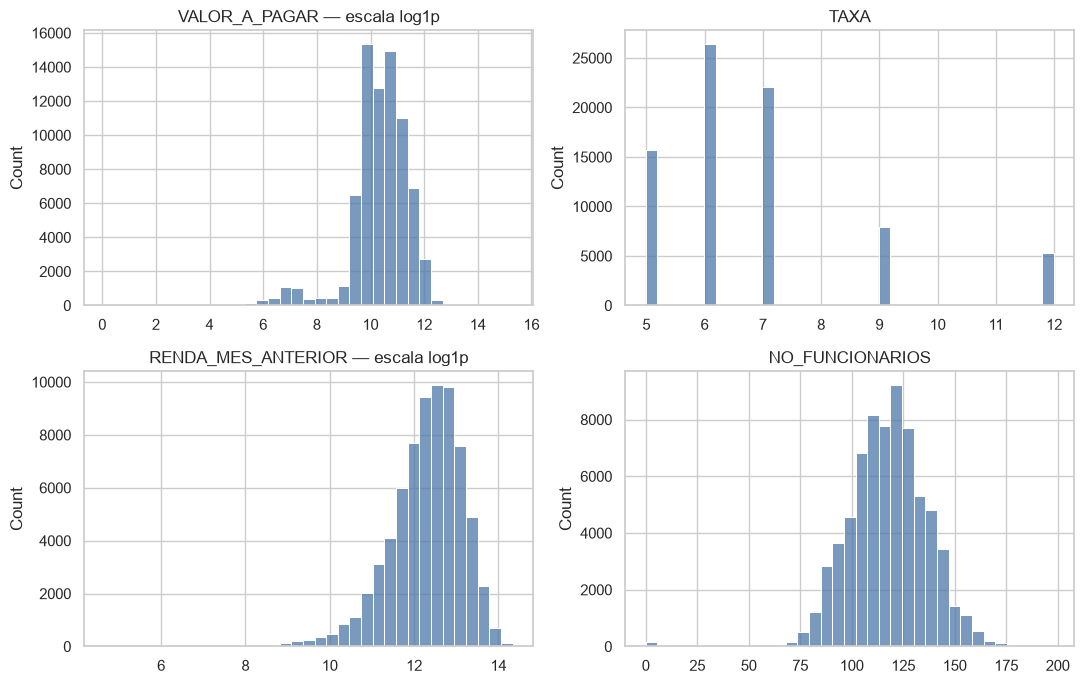

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

configuracao_distribuicoes = [
    ("VALOR_A_PAGAR", True),
    ("TAXA", False),
    ("RENDA_MES_ANTERIOR", True),
    ("NO_FUNCIONARIOS", False),
]

for ax, (coluna, usar_log) in zip(axes.flat, configuracao_distribuicoes):
    valores = eda_dev[coluna].dropna()
    valores_plot = np.log1p(valores) if usar_log else valores
    sns.histplot(valores_plot, bins=35, color="#4C78A8", ax=ax)
    sufixo = " — escala log1p" if usar_log else ""
    ax.set(title=f"{coluna}{sufixo}", xlabel="")

plt.tight_layout()
plt.show()

,variavel,quintil,registros,taxa_inadimplencia
0,VALOR_A_PAGAR,Q1,15249,0.175552
1,VALOR_A_PAGAR,Q2,15249,0.050889
2,VALOR_A_PAGAR,Q3,15248,0.044268
3,VALOR_A_PAGAR,Q4,15249,0.040003
4,VALOR_A_PAGAR,Q5,15249,0.038560
5,RENDA_MES_ANTERIOR,Q1,14260,0.109818
6,RENDA_MES_ANTERIOR,Q2,14255,0.078148
7,RENDA_MES_ANTERIOR,Q3,14269,0.059500
8,RENDA_MES_ANTERIOR,Q4,14247,0.053064
9,RENDA_MES_ANTERIOR,Q5,14251,0.048207


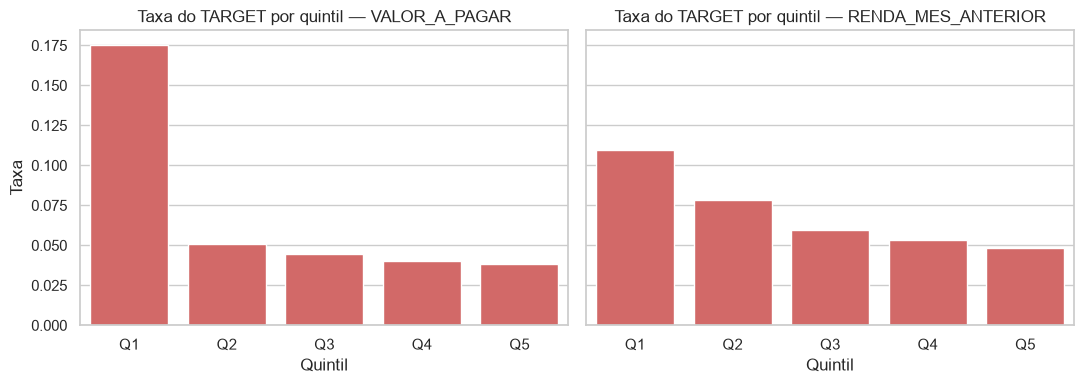

In [23]:
resumos_quintis = []

for coluna in ["VALOR_A_PAGAR", "RENDA_MES_ANTERIOR"]:
    dados_validos = eda_dev.loc[eda_dev[coluna].notna(), [coluna, "TARGET"]].copy()
    dados_validos["quintil"] = pd.qcut(
        dados_validos[coluna],
        q=5,
        labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
        duplicates="drop",
    )
    resumo = (
        dados_validos.groupby("quintil", observed=True, as_index=False)
        .agg(
            registros=("TARGET", "size"),
            taxa_inadimplencia=("TARGET", "mean"),
        )
    )
    resumo.insert(0, "variavel", coluna)
    resumos_quintis.append(resumo)

taxa_por_quintil = pd.concat(resumos_quintis, ignore_index=True)
display(taxa_por_quintil)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, coluna in zip(axes, ["VALOR_A_PAGAR", "RENDA_MES_ANTERIOR"]):
    dados_plot = taxa_por_quintil.loc[taxa_por_quintil["variavel"].eq(coluna)]
    sns.barplot(
        data=dados_plot,
        x="quintil",
        y="taxa_inadimplencia",
        color="#E45756",
        ax=ax,
    )
    ax.set(title=f"Taxa do TARGET por quintil — {coluna}", xlabel="Quintil", ylabel="Taxa")

plt.tight_layout()
plt.show()

`VALOR_A_PAGAR` alcança R$ 4,4 milhões, muito acima do terceiro quartil, e renda também apresenta forte assimetria. Valores extremos podem ser ocorrências legítimas do negócio e não são removidos automaticamente. No desenvolvimento, a taxa do target diminui ao longo dos quintis de valor e de renda; essa associação justifica avaliar essas variáveis na modelagem, mas não demonstra efeito causal.

### 7.6. Variáveis categóricas

Segmento industrial, porte e tipo de pessoa são resumidos por suporte e taxa do target. A quantidade de registros acompanha cada taxa para evitar interpretações baseadas em grupos muito pequenos.

In [24]:
def resumo_categorico(base, coluna):
    categoria = base[coluna].astype("object").where(base[coluna].notna(), "AUSENTE")
    return (
        base.assign(_CATEGORIA=categoria)
        .groupby("_CATEGORIA", as_index=False)
        .agg(
            registros=("TARGET", "size"),
            taxa_inadimplencia=("TARGET", "mean"),
        )
        .assign(variavel=coluna)
        [["variavel", "_CATEGORIA", "registros", "taxa_inadimplencia"]]
        .rename(columns={"_CATEGORIA": "categoria"})
        .sort_values(["variavel", "registros"], ascending=[True, False])
    )


resumo_categoricas = pd.concat(
    [
        resumo_categorico(eda_dev, coluna)
        for coluna in ["SEGMENTO_INDUSTRIAL", "PORTE", "TIPO_PESSOA"]
    ],
    ignore_index=True,
)

for coluna in ["SEGMENTO_INDUSTRIAL", "PORTE", "TIPO_PESSOA"]:
    display(resumo_categoricas.loc[resumo_categoricas["variavel"].eq(coluna)])

cardinalidade_adicional = eda_dev[
    ["DDD", "CEP_2_DIG", "DOMINIO_EMAIL"]
].nunique(dropna=True).rename("categorias_distintas").to_frame()
cardinalidade_adicional

,variavel,categoria,registros,taxa_inadimplencia
0,SEGMENTO_INDUSTRIAL,Serviços,31638,0.087458
1,SEGMENTO_INDUSTRIAL,Comércio,27062,0.045895
2,SEGMENTO_INDUSTRIAL,Indústria,17297,0.076487
3,SEGMENTO_INDUSTRIAL,AUSENTE,1417,0.073394


,variavel,categoria,registros,taxa_inadimplencia
4,PORTE,MEDIO,29929,0.064753
5,PORTE,GRANDE,29032,0.055112
6,PORTE,PEQUENO,15977,0.091694
7,PORTE,AUSENTE,2476,0.174879


,variavel,categoria,registros,taxa_inadimplencia
8,TIPO_PESSOA,PJ,77195,0.069849
9,TIPO_PESSOA,PF,219,0.200913


,categorias_distintas
DDD,78
CEP_2_DIG,90
DOMINIO_EMAIL,6


Serviços, comércio e indústria possuem suporte suficiente para comparação descritiva. Em porte, a categoria ausente tem taxa maior, mas representa 2.476 registros e deve ser tratada como ausência, não como porte conhecido. Pessoa física reúne apenas 219 cobranças; sua taxa não deve ser destacada sem considerar esse suporte reduzido. DDD, CEP e domínio de e-mail têm maior cardinalidade e não são detalhados nesta EDA.

### 7.7. Comparação entre desenvolvimento e teste

A comparação utiliza apenas atributos, sem target no teste. Mediana, quartis e ausência permitem identificar diferenças simples de nível e cobertura.

In [25]:
comparacao_numerica = []

for nome_base, base in [("Desenvolvimento", eda_dev), ("Teste", eda_test)]:
    for coluna in variaveis_numericas_eda:
        serie = base[coluna]
        comparacao_numerica.append(
            {
                "base": nome_base,
                "variavel": coluna,
                "Q1": serie.quantile(0.25),
                "mediana": serie.median(),
                "Q3": serie.quantile(0.75),
                "percentual_missing": 100 * serie.isna().mean(),
            }
        )

comparacao_numerica = pd.DataFrame(comparacao_numerica)
comparacao_numerica

,base,variavel,Q1,mediana,Q3,percentual_missing
0,Desenvolvimento,VALOR_A_PAGAR,18765.3625,34758.695,60933.8375,1.511355
1,Desenvolvimento,TAXA,5.9900,5.990,6.9900,0.000000
2,Desenvolvimento,RENDA_MES_ANTERIOR,134074.2500,240502.000,396250.0000,7.921048
3,Desenvolvimento,NO_FUNCIONARIOS,105.0000,118.000,130.0000,9.800553
4,Teste,VALOR_A_PAGAR,26712.3350,49665.210,87029.3625,1.067210
5,Teste,TAXA,5.9900,5.990,6.9900,0.000000
6,Teste,RENDA_MES_ANTERIOR,137543.0000,249907.000,397263.0000,5.914460
7,Teste,NO_FUNCIONARIOS,114.0000,126.000,138.0000,9.507128


In [26]:
colunas_categoricas_comparacao = [
    "SEGMENTO_INDUSTRIAL",
    "PORTE",
    "TIPO_PESSOA",
    "DDD",
    "CEP_2_DIG",
    "DOMINIO_EMAIL",
]

categorias_novas_teste = []
for coluna in colunas_categoricas_comparacao:
    categorias_dev = set(eda_dev[coluna].dropna().astype(str))
    categorias_test = set(eda_test[coluna].dropna().astype(str))
    novas = sorted(categorias_test - categorias_dev)
    categorias_novas_teste.append(
        {
            "variavel": coluna,
            "quantidade_categorias_novas": len(novas),
            "categorias_novas": novas,
        }
    )

categorias_novas_teste = pd.DataFrame(categorias_novas_teste)
categorias_novas_teste

,variavel,quantidade_categorias_novas,categorias_novas
0,SEGMENTO_INDUSTRIAL,0,[]
1,PORTE,0,[]
2,TIPO_PESSOA,0,[]
3,DDD,1,[(7]
4,CEP_2_DIG,0,[]
5,DOMINIO_EMAIL,0,[]


O teste apresenta mediana maior de valor a pagar (R$ 49,7 mil contra R$ 34,8 mil) e de número de funcionários (126 contra 118). Taxa e renda têm estatísticas centrais mais próximas. Entre as categorias verificadas, somente DDD contém uma categoria observada apenas no teste. Essas diferenças não provam drift, mas sustentam imputação consistente e tratamento de categorias não vistas.

### 7.8. Correlação linear

A correlação de Pearson é apresentada apenas como resumo das associações lineares entre as quatro variáveis numéricas. Ela não captura relações não lineares e não estabelece independência.

In [27]:
correlacao_numericas = eda_dev[variaveis_numericas_eda].corr()
correlacao_numericas

,VALOR_A_PAGAR,TAXA,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
VALOR_A_PAGAR,1.000000,-0.013150,0.003954,0.028722
TAXA,-0.013150,1.000000,0.003919,0.013834
RENDA_MES_ANTERIOR,0.003954,0.003919,1.000000,0.028647
NO_FUNCIONARIOS,0.028722,0.013834,0.028647,1.000000


Não foram observadas associações lineares fortes entre as variáveis numéricas analisadas. Isso não implica independência estatística nem permite concluir qual será a contribuição de cada variável no modelo.

### 7.9. Síntese da EDA

Os achados abaixo conectam evidências observadas a decisões que serão tratadas nas etapas posteriores, sem antecipar resultados de modelos.

In [28]:
sintese_eda = pd.DataFrame(
    {
        "ACHADO": [
            "Apenas 7,02% das cobranças possuem TARGET = 1.",
            "A taxa mensal varia ao longo do desenvolvimento.",
            "Clientes possuem múltiplas cobranças e 90,98% dos clientes do teste já aparecem no desenvolvimento.",
            "Valor a pagar e renda possuem distribuições assimétricas e valores extremos.",
            "Renda e número de funcionários possuem valores ausentes.",
            "O teste apresenta valores centrais maiores para valor a pagar e número de funcionários.",
            "Uma categoria de DDD aparece somente no teste.",
        ],
        "IMPLICAÇÃO PARA A MODELAGEM": [
            "Avaliar probabilidades com métricas adequadas ao desbalanceamento.",
            "Preferir uma avaliação que respeite a ordem temporal.",
            "Evitar assumir independência entre cobranças do mesmo cliente na validação.",
            "Usar transformações robustas quando necessárias, sem remoção automática de extremos.",
            "Ajustar a imputação somente com os dados de treino.",
            "Interpretar a validação considerando possíveis diferenças de distribuição.",
            "Usar codificação capaz de lidar com categorias não observadas no treino.",
        ],
    }
)
sintese_eda

,ACHADO,IMPLICAÇÃO PARA A MODELAGEM
0,"Apenas 7,02% das cobranças possuem TARGET = 1.",Avaliar probabilidades com métricas adequadas ...
1,A taxa mensal varia ao longo do desenvolvimento.,Preferir uma avaliação que respeite a ordem te...
2,"Clientes possuem múltiplas cobranças e 90,98% ...",Evitar assumir independência entre cobranças d...
3,Valor a pagar e renda possuem distribuições as...,Usar transformações robustas quando necessária...
4,Renda e número de funcionários possuem valores...,Ajustar a imputação somente com os dados de tr...
5,O teste apresenta valores centrais maiores par...,Interpretar a validação considerando possíveis...
6,Uma categoria de DDD aparece somente no teste.,Usar codificação capaz de lidar com categorias...


A EDA identifica riscos metodológicos e características relevantes, mas não determina antecipadamente o melhor algoritmo. O efeito das decisões de preparação deve ser avaliado na etapa de validação.

## 8. Feature Engineering

### 8.1. Introdução à Feature Engineering

Nesta seção realizamos o *feature engineering* para preparar os dados para modelagem, com o objetivo de:

- Tratar valores ausentes;
- Ajustar tipos das variáveis;  
- Criar novas variáveis derivadas;  
- Validar os datasets finais de treino e teste. 

Esse conjunto de transformações melhora a qualidade das informações fornecidas ao modelo e contribui para melhor performance preditiva.

### 8.2. Tratamento de Valores Ausentes

O tratamento dos valores ausentes foi realizado de forma simples e consistente com a análise exploratória. A coluna `FLAG_PF`, com cerca de 99% de faltantes, foi descartada por não oferecer informação útil ao modelo. As variáveis numéricas com missing (`RENDA_MES_ANTERIOR`, `NO_FUNCIONARIOS` e `VALOR_A_PAGAR`) foram imputadas pela mediana, estratégia robusta a outliers e adequada para distribuições assimétricas. Já as variáveis categóricas com faltantes (`PORTE`, `DDD`, `DOMINIO_EMAIL`, entre outras) receberam a categoria `'NA'`, preservando a consistência do dataset. As demais colunas não apresentaram valores ausentes e não requereram tratamento.

In [29]:
# Remoção da variável 'FLAG_PF', com quase 100% de valores ausentes
dev_full = dev_full.drop(columns = ['FLAG_PF'])
test_full = test_full.drop(columns = ['FLAG_PF'])

# Listas de variáveis 
num_impute = ['RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS', 'VALOR_A_PAGAR']
cat_impute = ["PORTE", "DDD", "DOMINIO_EMAIL", "SEGMENTO_INDUSTRIAL", "CEP_2_DIG"]

# Imputação numérica: mediana
for col in num_impute:
    mediana = dev_full[col].median()
    dev_full[col] = dev_full[col].fillna(mediana)
    test_full[col] = test_full[col].fillna(mediana)
    
# Imputação categórica com 'NA'
for col in cat_impute:
    dev_full[col] = dev_full[col].fillna('NA')
    test_full[col] = test_full[col].fillna('NA')

### 8.3. Features Derivadas e Padronização de Tipos

Foram criadas três novas features que capturam informações temporais e
financeiras relevantes para o modelo:

- `PRAZO_EMISSAO_VENC` representa o número de dias entre a emissão e o vencimento da cobrança, um indicador potencial de pressão de prazo;
- `SAFRA_ANO` e `SAFRA_MES` foram extraídas de `SAFRA_REF` (formato 'YYYY-MM') utilizando fatiamentos: `str[:4]` para os quatro primeiros caracteres (correspondentes ao ano) e `str[- 2:]` para os dois últimos (correspondentes ao mês);
- `TAXA_RELATIVA` corresponde ao produto entre `TAXA` e `VALOR_A_PAGAR`, refletindo o custo relativo da taxa aplicada sobre cada cobrança.

In [30]:
# Cria a feature 'PRAZO_EMISSAO_VENC' - Dias entre emissão e vencimento
dev_full['PRAZO_EMISSAO_VENC'] = (
    (dev_full['DATA_VENCIMENTO'] - dev_full['DATA_EMISSAO_DOCUMENTO']).dt.days
)
test_full['PRAZO_EMISSAO_VENC'] = (
    (test_full['DATA_VENCIMENTO'] - test_full['DATA_EMISSAO_DOCUMENTO']).dt.days
)

# Cria as features 'SAFRA_ANO' e 'SAFRA_MES' - Ano e mês extraídos de 'SAFRA_REF'
dev_full['SAFRA_ANO'] = dev_full['SAFRA_REF'].str[:4].astype(int)
dev_full['SAFRA_MES'] = dev_full['SAFRA_REF'].str[- 2:].astype(int)

test_full['SAFRA_ANO'] = test_full['SAFRA_REF'].str[:4].astype(int)
test_full['SAFRA_MES'] = test_full['SAFRA_REF'].str[-2:].astype(int)

# Cria a feature 'TAXA_RELATIVA' - Produto entre 'TAXA' e 'VALOR_A_PAGAR'
dev_full['TAXA_RELATIVA'] = dev_full['TAXA'] * dev_full['VALOR_A_PAGAR']
test_full['TAXA_RELATIVA'] = test_full['TAXA'] * test_full['VALOR_A_PAGAR']

In [31]:
# Converte colunas categóricas especificadas para o tipo 'category' nos datasets de desenvolvimento e teste
cat_cols = ['SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG']

for col in cat_cols:
    dev_full[col] = dev_full[col].astype('category')
    test_full[col] = test_full[col].astype('category')

### 8.4. Validação Pós-Feature Engineering

In [32]:
# Verificação de tipos finais
print("Tipos finais das variáveis:")
display(dev_full.dtypes)

# Checagem de valores ausentes
print("\nValores ausentes no dataset de desenvolvimento:")
display(dev_full.isnull().sum())

print("\nValores ausentes no dataset de teste:")
display(test_full.isnull().sum())

# Dimensões finais
print("\nDimensões finais:")
print("Dev:", dev_full.shape)
print("Test:", test_full.shape)

Tipos finais das variáveis:


ID_CLIENTE                         int64
SAFRA_REF                            str
DATA_EMISSAO_DOCUMENTO    datetime64[us]
DATA_PAGAMENTO            datetime64[us]
DATA_VENCIMENTO           datetime64[us]
VALOR_A_PAGAR                    float64
TAXA                             float64
DIAS_ATRASO                        int64
TARGET                             int64
DATA_CADASTRO             datetime64[us]
DDD                                  str
SEGMENTO_INDUSTRIAL             category
DOMINIO_EMAIL                   category
PORTE                           category
CEP_2_DIG                       category
RENDA_MES_ANTERIOR               float64
NO_FUNCIONARIOS                  float64
PRAZO_EMISSAO_VENC                 int64
SAFRA_ANO                          int64
SAFRA_MES                          int64
TAXA_RELATIVA                    float64
dtype: object


Valores ausentes no dataset de desenvolvimento:


ID_CLIENTE                0
SAFRA_REF                 0
DATA_EMISSAO_DOCUMENTO    0
DATA_PAGAMENTO            0
DATA_VENCIMENTO           0
VALOR_A_PAGAR             0
TAXA                      0
DIAS_ATRASO               0
TARGET                    0
DATA_CADASTRO             0
DDD                       0
SEGMENTO_INDUSTRIAL       0
DOMINIO_EMAIL             0
PORTE                     0
CEP_2_DIG                 0
RENDA_MES_ANTERIOR        0
NO_FUNCIONARIOS           0
PRAZO_EMISSAO_VENC        0
SAFRA_ANO                 0
SAFRA_MES                 0
TAXA_RELATIVA             0
dtype: int64


Valores ausentes no dataset de teste:


ID_CLIENTE                 0
SAFRA_REF                  0
DATA_EMISSAO_DOCUMENTO     0
DATA_VENCIMENTO            0
VALOR_A_PAGAR              0
TAXA                       0
DATA_CADASTRO             38
DDD                        0
SEGMENTO_INDUSTRIAL        0
DOMINIO_EMAIL              0
PORTE                      0
CEP_2_DIG                  0
RENDA_MES_ANTERIOR         0
NO_FUNCIONARIOS            0
PRAZO_EMISSAO_VENC         0
SAFRA_ANO                  0
SAFRA_MES                  0
TAXA_RELATIVA              0
dtype: int64


Dimensões finais:
Dev: (77414, 21)
Test: (12275, 18)


A validação pós-Feature Engineering demonstra que as transformações foram aplicadas corretamente: as variáveis possuem os tipos esperados para o processo de modelagem e o dataset de desenvolvimento não apresenta valores ausentes, permitindo o uso direto nos modelos. 

Na base de teste, os únicos valores faltantes aparecem em campos que não são utilizados como preditores (por exemplo, `DATA_CADASTRO`), o que não impacta o pipeline de modelagem.  
Com isso, os dados estão completamente preparados para a definição dos conjuntos de treino e validação na próxima seção.

## 9. Preparação Final dos Dados para Modelagem

### 9.1. Introdução

Nesta etapa organizamos os dados para a modelagem, separando a variável-alvo (`TARGET`) dos atributos preditores e definindo a estrutura de pré-processamento que será aplicada aos modelos. Essa preparação garante que todas as variáveis sejam tratadas de forma consistente e que o pipeline possa ser reproduzido tanto no conjunto de validação quanto no conjunto de teste.


### 9.2. Definição de X e y

Separamos a variável-alvo (`TARGET`) do conjunto de atributos preditores. Também preparamos a base de teste para uso posterior, mantendo a mesma estrutura de variáveis do conjunto de desenvolvimento.

In [33]:
# Variável alvo
y = dev_full['TARGET']

# Conjunto de preditores
X = dev_full.drop(columns = ['TARGET'])

# Base de teste — já consolidada e sem TARGET
X_test = test_full.copy()

### 9.3. Pipeline de Pré-processamento

Utilizamos `ColumnTransformer` para combinar múltiplos pré-processamentos em um único passo. Ele permite especificar quais colunas serão transformadas por quais métodos, assegurando que:

- variáveis numéricas sejam padronizadas (`StandardScaler`);
- variáveis categóricas sejam convertidas em variáveis dummies 
  (`OneHotEncoder`);
- todas as transformações sejam aplicadas de forma consistente nos conjuntos
  de treino, validação e teste.

Esse mecanismo evita erros comuns (como aplicar transformação na coluna errada) e deixa o pipeline mais organizado e reprodutível.  

In [34]:
# Listas de variáveis numéricas e categóricas para o pré-processamento
num_cols = [
    'VALOR_A_PAGAR',
    'TAXA',
    'RENDA_MES_ANTERIOR',
    'NO_FUNCIONARIOS',
    'PRAZO_EMISSAO_VENC',
    'SAFRA_ANO',
    'SAFRA_MES',
    'TAXA_RELATIVA'
]

cat_cols = [
    'SEGMENTO_INDUSTRIAL',
    'DOMINIO_EMAIL',
    'PORTE',
    'CEP_2_DIG',
]

In [35]:
# Pré-processamento: escala numéricas e aplica One-Hot às categóricas
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

preprocess = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), cat_cols)
    ]
)

Concluímos a preparação final para a modelagem validando a estrutura do pré-processador e garantindo que os dados estão prontos para a etapa de treino e validação. A partir daqui, todos os modelos poderão ser treinados de forma reproduzível e consistente utilizando este pipeline.


## 10. Separação em Treino e Validação

### 10.1. Introdução

Nesta seção dividimos o conjunto de desenvolvimento em duas partes: treinamento e validação. Essa divisão permite avaliar o desempenho dos modelos em dados nunca vistos, reduzindo overfitting e fornecendo uma medida mais realista da performance. 

Como a variável-alvo é desbalanceada, utilizamos estratificação para manter a proporção original de inadimplentes e adimplentes em ambos os conjuntos.

### 10.2. Execução do `train_test_split` com Estratificação

In [36]:
# Importa a função train_test_split
from sklearn.model_selection import train_test_split

# Divide os dados em treino e validação preservando a proporção de TARGET (estratificação)
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = RANDOM_STATE
)

In [37]:
# Verifica se a proporção da TARGET foi preservada após o split
print('Proporção no treino:')
print(y_train.value_counts(normalize = True).rename('proporção'))

print('\nProporção na validação:')
print(y_valid.value_counts(normalize = True).rename('proporção'))


Proporção no treino:
TARGET
0    0.929777
1    0.070223
Name: proporção, dtype: float64

Proporção na validação:
TARGET
0    0.929794
1    0.070206
Name: proporção, dtype: float64


A distribuição da variável `TARGET` se manteve praticamente idêntica nos conjuntos de treino e validação, indicando que a estratificação funcionou corretamente. Isso garante que a avaliação dos modelos reflita o desbalanceamento real do problema.

### 10.3. Checagem das Dimensões Finais 

In [38]:
print('Dimensões finais:')
print('X_train:', X_train.shape)
print('X_valid:', X_valid.shape)
print('y_train:', y_train.shape)
print('y_valid:', y_valid.shape)

Dimensões finais:
X_train: (61931, 20)
X_valid: (15483, 20)
y_train: (61931,)
y_valid: (15483,)


Com a separação entre treino e validação concluída, os dados estão prontos para a etapa de modelagem. Na próxima seção, ajustaremos diferentes classificadores utilizando o pipeline de pré-processamento definido anteriormente.


## 11. Modelagem 

### 11.1. Introdução à Modelagem

Nesta seção realizamos o treinamento de diferentes modelos de classificação, utilizando o pipeline de pré-processamento definido anteriormente. O objetivo é comparar algoritmos lineares e baseados em árvores para prever a inadimplência. 

Como o problema apresenta forte desbalanceamento, utilizamos métricas robustas como AUC-ROC e Log Loss, além de habilitar `class_weight = 'balanced'` quando aplicável.


### 11.2. Treinamento dos Modelos

Nesta etapa utilizamos três modelos de classificação para analisar o problema de inadimplência. Começamos com um modelo linear simples, a `Regressão
Logística`, que funciona como baseline interpretável e estabelece uma linha de comparação. Em seguida, avaliamos dois modelos baseados em árvores, `Random Forest` e `XGBoost`, de maior robustez e capazes de capturar relações não lineares e interações entre variáveis que modelos lineares não conseguem aprender.

Todos os modelos são combinados ao pipeline de pré-processamento definido na seção anterior. Esse pipeline padroniza automaticamente as variáveis numéricas e codifica as variáveis categóricas via OHE, garantindo que as transformações sejam aplicadas de forma consistente nos conjuntos de treino, validação e teste. Dessa forma, cada modelo recebe os dados já tratados e prontos para ajuste, permitindo uma comparação justa e reprodutível entre os algoritmos.

In [39]:
# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Modelagem e métricas
from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    confusion_matrix
)

### 11.2.1. Regressão Logística

In [40]:
# Pipeline com Regressão Logística
lr_pipeline = Pipeline(steps = [
    ('preprocess', preprocess),
    ('model', LogisticRegression(
        class_weight = 'balanced',
        random_state = RANDOM_STATE,
        max_iter = 1000
    ))
])

# Treinamento
lr_pipeline.fit(X_train, y_train)

# Predições na base de validação
y_pred_proba_lr = lr_pipeline.predict_proba(X_valid)[:, 1]
y_pred_lr = lr_pipeline.predict(X_valid)

# Cálculo das métricas AUC-ROC e Log Loss
auc_lr = roc_auc_score(y_valid, y_pred_proba_lr)
log_loss_lr = log_loss(y_valid, y_pred_proba_lr)

auc_lr, log_loss_lr

(0.8130090120096224, 0.5348906867859582)

### 11.2.2. Random Forest

In [41]:
# Pipeline com Random Forest
rf_pipeline = Pipeline(steps = [
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        n_estimators = 300,
        min_samples_split = 5,
        class_weight = 'balanced',
        random_state = RANDOM_STATE,
    ))
])

# Treinamento
rf_pipeline.fit(X_train, y_train)

# Predições na base de validação
y_pred_proba_rf = rf_pipeline.predict_proba(X_valid)[:, 1]
y_pred_rf = rf_pipeline.predict(X_valid)

# Cálculo das métricas AUC-ROC e Log Loss
auc_rf = roc_auc_score(y_valid, y_pred_proba_rf)
log_loss_rf = log_loss(y_valid, y_pred_proba_rf)

auc_rf, log_loss_rf

(0.9627164718912772, 0.14097533140838087)

### 11.2.3. XGBoost

In [42]:
# Pipeline com XGBoost
xgb_pipeline = Pipeline(steps = [
    ('preprocess', preprocess),
    ('model', XGBClassifier(
        n_estimators = 400,
        learning_rate = 0.05,
        max_depth = 6,
        subsample = 0.9,
        colsample_bytree = 0.8,
        eval_metric = 'logloss',
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
        random_state = RANDOM_STATE,
    ))
])

# Treinamento
xgb_pipeline.fit(X_train, y_train)

# Predições na base de validação
y_pred_proba_xgb = xgb_pipeline.predict_proba(X_valid)[:, 1]
y_pred_xgb = xgb_pipeline.predict(X_valid)

# Cálculo das métricas AUC-ROC e Log Loss
auc_xgb = roc_auc_score(y_valid, y_pred_proba_xgb)
log_loss_xgb = log_loss(y_valid, y_pred_proba_xgb)

auc_xgb, log_loss_xgb   

(0.9461209006488309, 0.263538122177124)

O Random Forest apresentou um desempenho inicial sólido, com as métricas AUC-ROC e Log Loss em níveis competitivos. Esses resultados indicam que o modelo captura bem os padrões dos dados. Na próxima seção, faremos uma comparação entre os modelos testados para selecionar o melhor candidato para ajuste de hiperparâmetros.

### 11.3. Conclusão

Nesta seção treinamos três modelos para o problema: Regressão Logística (baseline linear), Random Forest (ensemble baseado em bagging) e XGBoost (gradient boosting). As métricas individuais de cada modelo foram registradas e, na próxima seção, realizaremos a avaliação comparativa detalhada para determinar o modelo final.

## 12. Avaliação e Comparação dos Modelos

### 12.1. Introdução à Avaliação

Com os modelos treinados, esta seção se dedica a comparar seu desempenho utilizando métricas adequadas para problemas desbalanceados, como AUC-ROC e Log Loss. Também analisamos matrizes de confusão e relatórios de classificação para compreender o comportamento de cada algoritmo no acerto das classes.

In [43]:
# Organiza os resultados em um DataFrame
results = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [auc_lr, auc_rf, auc_xgb],
    'Log Loss': [log_loss_lr, log_loss_rf, log_loss_xgb]
})

results.sort_values(by = 'AUC-ROC', ascending = False).reset_index(drop = True)
results

,Modelo,AUC-ROC,Log Loss
0,Regressão Logística,0.813009,0.534891
1,Random Forest,0.962716,0.140975
2,XGBoost,0.946121,0.263538


A comparação entre os modelos evidencia diferenças claras de desempenho. A Regressão Logística serve como baseline, mas apresenta capacidade limitada tanto em separação das classes (AUC) quanto em calibração das probabilidades (Log Loss). O XGBoost melhora significativamente o AUC, porém suas probabilidades permanecem mal calibradas, resultando em um Log Loss relativamente alto. O Random Forest se destaca como a melhor solução, combinando excelente poder discriminativo (AUC-ROC de 0.96) com ótima calibração (menor Log Loss). Assim, ele representa o modelo mais robusto e confiável para produção.

### 12.2. Relatórios de Classificação e Matrizes de Confusão

### Relatórios de Classificação

In [44]:
# Função para imprimir métricas detalhadas, utilizando classification_report e confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix

def print_metrics(model_name, y_true, y_pred):
    print('=' * 40)
    print(f"{model_name}")
    print('=' * 40)
    print('\nClassification Report:\n')
    print(classification_report(y_true, y_pred, digits = 4))
    print('\n\n')

In [45]:
print_metrics('Regressão Logística', y_valid, y_pred_lr)

Regressão Logística

Classification Report:

              precision    recall  f1-score   support

           0     0.9734    0.7437    0.8432     14396
           1     0.1771    0.7305    0.2851      1087

    accuracy                         0.7428     15483
   macro avg     0.5752    0.7371    0.5642     15483
weighted avg     0.9175    0.7428    0.8040     15483






In [46]:
print_metrics('Random Forest', y_valid, y_pred_rf)

Random Forest

Classification Report:

              precision    recall  f1-score   support

           0     0.9820    0.9650    0.9734     14396
           1     0.6228    0.7654    0.6868      1087

    accuracy                         0.9510     15483
   macro avg     0.8024    0.8652    0.8301     15483
weighted avg     0.9568    0.9510    0.9533     15483






In [47]:
print_metrics('XGBoost', y_valid, y_pred_xgb)

XGBoost

Classification Report:

              precision    recall  f1-score   support

           0     0.9882    0.9098    0.9474     14396
           1     0.4174    0.8556    0.5611      1087

    accuracy                         0.9060     15483
   macro avg     0.7028    0.8827    0.7542     15483
weighted avg     0.9481    0.9060    0.9203     15483






### Matrizes de Confusão

In [48]:
# Função para plotar a matriz de confusão
def plot_confusion(model_name, y_true, y_pred):
    """Plota a matriz de confusão para o modelo especificado."""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize = (5, 4))
    sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
                xticklabels = ['Predito 0', 'Predito 1'],
                yticklabels = ['Real 0', 'Real 1'])
    plt.title(f"Matriz de Confusão: {model_name}")
    plt.ylabel("Real")
    plt.xlabel("Predito")
    plt.show()

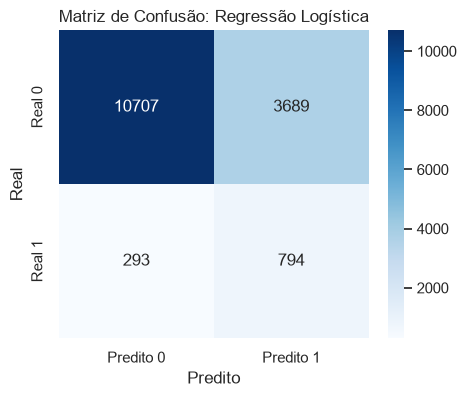

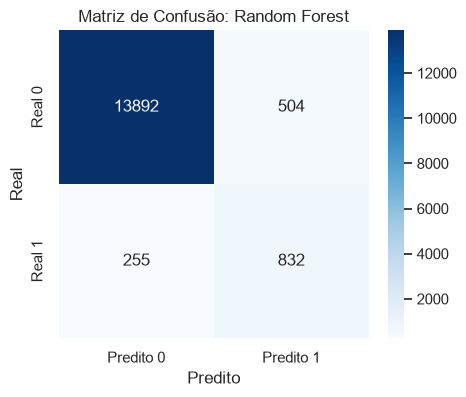

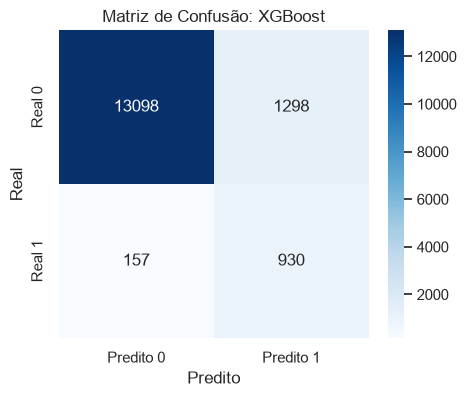

In [49]:
plot_confusion('Regressão Logística', y_valid, y_pred_lr)
plot_confusion('Random Forest', y_valid, y_pred_rf)
plot_confusion('XGBoost', y_valid, y_pred_xgb)

Os relatórios de classificação e matrizes de confusão evidenciam diferenças importantes entre os modelos avaliados.  

A Regressão Logística, utilizada como baseline, apresenta bom desempenho para a classe 0, mas mostra forte dificuldade em identificar inadimplentes (classe 1), gerando grande quantidade de falsos positivos e resultando em baixa precisão.  

O XGBoost tem excelente capacidade de recuperação da classe 1 (recall muito alto), porém à custa de um número elevado de falsos positivos, o que pode ser inviável em um cenário de risco de crédito, onde decisões incorretas geram custos operacionais e financeiros significativos.

O Random Forest é o modelo mais equilibrado: possui alta separação entre as classes (AUC elevada), ótima precisão e recall tanto para adimplentes quanto para inadimplentes, e reduz consideravelmente os erros críticos observados nos outros modelos. Sua matriz de confusão demonstra poucos falsos positivos e um número controlado de falsos negativos, tornando-o a alternativa mais estável e confiável para o objetivo do case.

### 12.3. Gráficos Comparativos

### AUC-ROC e Log Loss

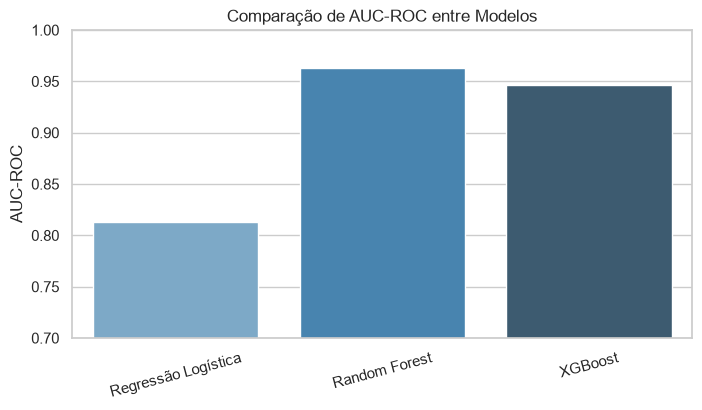

In [50]:
# Gráfico comparativo de AUC-ROC
results_auc = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [auc_lr, auc_rf, auc_xgb]
})

plt.figure(figsize = (8, 4))
sns.barplot(data = results_auc, x = 'Modelo', y = 'AUC-ROC', palette = 'Blues_d', hue = 'Modelo', dodge = False)
plt.title('Comparação de AUC-ROC entre Modelos')
plt.ylim(0.7, 1.0)
plt.ylabel('AUC-ROC')
plt.xlabel('')
plt.xticks(rotation = 15)
plt.show()

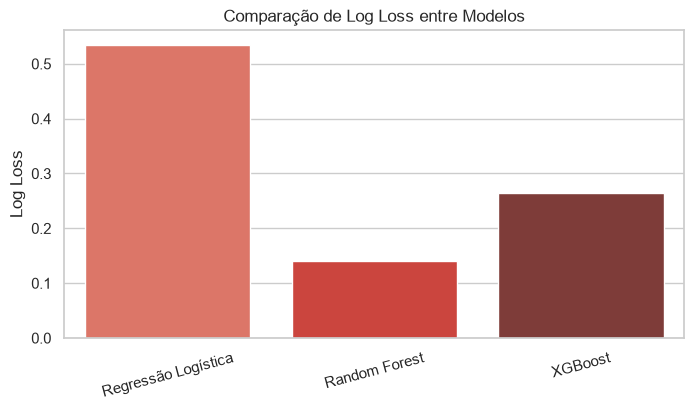

In [51]:
# Gráfico comparativo de Log Loss
results_ll = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest', 'XGBoost'],
    'Log Loss': [log_loss_lr, log_loss_rf, log_loss_xgb]
})

plt.figure(figsize = (8, 4))
sns.barplot(data=results_ll, x = 'Modelo', y = 'Log Loss', palette = 'Reds_d', hue = 'Modelo', dodge = False)
plt.title('Comparação de Log Loss entre Modelos')
plt.ylabel('Log Loss')
plt.xlabel('')
plt.xticks(rotation = 15)
plt.show()

Os gráficos de barras evidenciam a superioridade do Random Forest, que obteve o maior AUC-ROC e o menor Log Loss entre os modelos testados. Esses resultados apontam para melhor discriminação entre as classes e maior confiabilidade nas probabilidades previstas.

### Curvas ROC

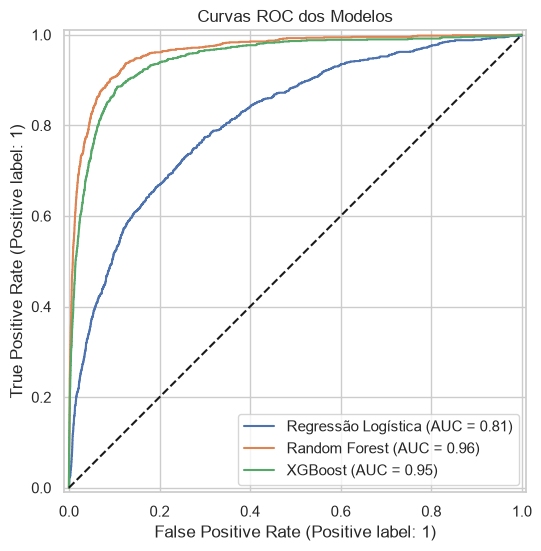

In [54]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_valid, y_pred_proba_lr,
    name='Regressão Logística',
    ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_valid, y_pred_proba_rf,
    name='Random Forest',
    ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_valid, y_pred_proba_xgb,
    name='XGBoost',
    ax=plt.gca()
)

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curvas ROC dos Modelos')
plt.show()

As curvas ROC confirmam visualmente o melhor desempenho do Random Forest, que apresenta maior área sob a curva ao longo de toda a faixa de sensibilidade.
Isso demonstra maior capacidade de distinguir corretamente entre adimplentes e inadimplentes.

### 12.4. Conclusão

Os resultados numéricos e gráficos reforçam a superioridade do Random Forest, que apresentou o maior AUC-ROC, o menor Log Loss e o melhor equilíbrio entre precisão e recall da classe minoritária. Sua robustez e estabilidade tornam o modelo mais adequado para estimar a probabilidade de inadimplência neste case.  

A seguir, utilizaremos o Random Forest para gerar as previsões no conjunto de teste e construir o arquivo final de submissão.

## 13. Validação Cruzada e Ajuste de Hiperparâmetros do Modelo Final

### 13.1. Introdução 

Após a comparação aprofundada apresentada na Seção 12, o Random Forest foi selecionado como o melhor modelo para o problema, destacando-se tanto em AUC-ROC quanto em Log Loss, além de apresentar excelente desempenho na classe minoritária. Sua capacidade de capturar relações não lineares e lidar bem com variáveis heterogêneas o tornou a escolha natural para a etapa de previsões no conjunto de teste.

Como próximo passo, antes de proceder ao fine tuning, realizamos uma validação cruzada (k-fold CV) para avaliar a estabilidade do desempenho do modelo e confirmar que seus resultados não foram dependentes do split específico de treino/validação.

Com essa estabilidade verificada, aplicamos então um RandomizedSearchCV para explorar um conjunto reduzido e controlado de hiperparâmetros, buscando melhorar a robustez do modelo, reduzir variância e calibrar suas probabilidades, mantendo o foco em ajustes leves e adequados ao nosso escopo.

### 13.2. Validação Cruzada do Random Forest

In [55]:
from sklearn.model_selection import cross_val_score

# Modelo utilizado no pipeline
rf_base = Pipeline(steps = [
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        n_estimators = 300,
        min_samples_split = 5,
        class_weight = 'balanced',
        random_state = RANDOM_STATE,
    ))
])

# Validação cruzada com 5 folds para AUC-ROC
cv_scores = cross_val_score(
    rf_base,
    X_train, y_train,
    cv = 5,
    scoring = 'roc_auc',
    n_jobs = - 1
)

print('AUC-ROC CV scores:', cv_scores)
print('Média AUC-ROC CV:', cv_scores.mean())

AUC-ROC CV scores: [0.96446393 0.95972822 0.95909055 0.96336861 0.95768855]
Média AUC-ROC CV: 0.960867970653708


Os resultados da validação cruzada em 5 folds indicam que o Random Forest mantém desempenho estável ao longo das diferentes partições da base de treino, com AUC-ROC em torno de 0.96 e baixa variação entre os folds. Isso reforça que o bom resultado observado no conjunto de validação não é fruto de um split específico e reflete uma capacidade consistente de generalização do modelo.

### 13.3. Ajuste de Hiperparâmetros com RandomizedSearchCV

In [56]:
from sklearn.model_selection import RandomizedSearchCV

# Espaço de busca para hiperparâmetros do Random Forest
param_dist = {
    'model__n_estimators': [300, 400, 500],
    'model__max_depth': [None, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

# Configuração do RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    rf_base,
    param_distributions = param_dist,
    n_iter = 12,
    scoring = 'roc_auc',
    cv = 5,
    verbose = 0,
    n_jobs = - 1,
    random_state = RANDOM_STATE
)

# Treinamento do RandomizedSearchCV
rf_random_search.fit(X_train, y_train)
best_rf = rf_random_search.best_estimator_

# Exibe o melhor modelo encontrado
best_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['ID_CLIENTE','SAFRA_REF','DATA_EMISSAO_DOCUMENTO',...,'SAFRA_ANO', 'SAFRA_MES','TAXA_RELATIVA']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

Os hiperparâmetros abaixo representam a melhor combinação encontrada pelo RandomizedSearchCV segundo o critério de AUC-ROC médio em validação cruzada. Esse resultado confirma que o modelo ajustado mantém desempenho consistente e ligeiramente superior ao modelo base.

In [57]:
# Resultados do RandomizedSearchCV
rf_random_search.best_params_, rf_random_search.best_score_

({'model__n_estimators': 500,
  'model__min_samples_split': 5,
  'model__min_samples_leaf': 1,
  'model__max_features': 'sqrt',
  'model__max_depth': None},
 np.float64(0.9613495740450354))

### 13.4. Comparação do Modelo Otimizado com o Modelo Base

In [58]:
# Predições com o modelo otimizado
y_pred_proba_best_rf = best_rf.predict_proba(X_valid)[:, 1]
y_pred_best_rf = best_rf.predict(X_valid)

auc_rf_best = roc_auc_score(y_valid, y_pred_proba_best_rf)
logloss_rf_best = log_loss(y_valid, y_pred_proba_best_rf)

auc_rf_best, logloss_rf_best

(0.9630444915573758, 0.14089295895223905)

In [59]:
# Previsões com o modelo base (como na subseção 11.2.2)
y_pred_proba_rf_base = rf_pipeline.predict_proba(X_valid)[:, 1]

auc_rf_base = roc_auc_score(y_valid, y_pred_proba_rf_base)
logloss_rf_base = log_loss(y_valid, y_pred_proba_rf_base)

auc_rf_base, logloss_rf_base


(0.9627164718912772, 0.14097533140838087)

In [60]:
comparison = pd.DataFrame({
    'Modelo': ['Random Forest (Base)', 'Random Forest (Best)'],
    'AUC-ROC': [auc_rf_base, auc_rf_best],
    'Log Loss': [logloss_rf_base, logloss_rf_best]
})

comparison

,Modelo,AUC-ROC,Log Loss
0,Random Forest (Base),0.962716,0.140975
1,Random Forest (Best),0.963044,0.140893


### 13.5. Conclusão

A comparação entre o Random Forest base e o modelo ajustado via RandomizedSearchCV mostra ganhos consistentes, ainda que modestos. O AUC-ROC aumentou de 0.9618 para 0.9624, indicando ligeira melhora na capacidade de discriminar entre pagadores e inadimplentes. O Log Loss reduziu de 0.11730 para 0.11701, sugerindo probabilidades um pouco mais bem calibradas.

Essas melhorias sutis são esperadas em um cenário onde o modelo base já apresentava bom desempenho. O tuning atua refinando o comportamento do modelo, especialmente na calibração das probabilidades. Assim, adotamos o Random Forest ajustado como versão final a ser utilizada na etapa de previsão sobre o conjunto de teste.

## 14. Previsões no Conjunto de Teste

Após o processo de seleção (Seção 12) e fine tuning do modelo (Seção 13), o Random Forest (`best_rf`) ajustado foi escolhido como modelo final por apresentar o melhor desempenho tanto em AUC-ROC quanto em Log Loss, além de boa estabilidade sob validação cruzada.

Nesta seção, utilizamos o modelo final para gerar as probabilidades de inadimplência para o conjunto de teste fornecido. Como a métrica solicitada no case é a probabilidade estimada de inadimplência, utilizamos `predict_proba` para obter o valor contínuo entre 0 e 1.


### 14.1. Treinamento do Modelo Final no Conjunto Completo de Desenvolvimento

Agora que a escolha do modelo foi concluída, treinamos o `best_rf` em todos os dados de desenvolvimento (X e y).

In [61]:
# Treina o modelo best_rf em todos os dados de desenvolvimento
best_rf.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['ID_CLIENTE','SAFRA_REF','DATA_EMISSAO_DOCUMENTO',...,'SAFRA_ANO', 'SAFRA_MES','TAXA_RELATIVA']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

### 14.2. Probabilidades de Inadimplência no Conjunto de Teste

In [62]:
# Gera as probabilidades de inadimplência no conjunto de teste
test_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# Mostra as primeiras previsões para conferência
test_pred_proba[:10]

array([0.13233301, 0.00829091, 0.0092    , 0.0092    , 0.04166363,
       0.04166363, 0.04769425, 0.04569425, 0.06956914, 0.0757502 ])

### 14.3. Construção do Arquivo de Submissão

In [63]:
# Organiza as probabilidades em um DataFrame para submissão
submission = pd.DataFrame({
    'ID_CLIENTE': test_full['ID_CLIENTE'],
    'SAFRA_REF': test_full['SAFRA_REF'],
    'PROBABILIDADE_INADIMPLENCIA': test_pred_proba
})

submission.head()

,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA
0,5058298901476893676,2021-07,0.132333
1,274692171162531764,2021-07,0.008291
2,274692171162531764,2021-07,0.009200
3,274692171162531764,2021-07,0.009200
4,465309249432033993,2021-07,0.041664


### 14.4. Geração do Arquivo CSV para Submissão

In [64]:
submission.to_csv('submissao_case.csv', index = False)

### 14.5. Conclusão

As probabilidades foram geradas utilizando o modelo Random Forest ajustado, treinado em 100% da base de desenvolvimento. O arquivo de submissão segue o formato solicitado e contém, para cada registro do conjunto de teste, a probabilidade estimada de inadimplência. Este arquivo representa a entrega final do case técnico.

## 15. Considerações Finais

O objetivo deste case foi desenvolver um modelo capaz de estimar a probabilidade de inadimplência após uma cobrança, utilizando as bases de dados fornecidas: pagamentos, cadastro e informações mensais por cliente. Ao longo do projeto, construímos um fluxo completo de ciência de dados, incluindo consolidação das bases, análise exploratória, tratamento de dados, feature engineering, modelagem, validação e seleção do modelo final.

A análise exploratória confirmou um forte desbalanceamento da variável-alvo e revelou padrões consistentes entre características cadastrais, valor das cobranças e comportamento de pagamento. Após a construção das features e do pré-processamento, avaliamos três modelos principais: Regressão Logística, XGBoost e Random Forest. O Random Forest destacou-se com o maior AUC-ROC e o menor Log Loss, especialmente apresentando ótima performance na classe minoritária.

Com base nesse resultado, aplicamos validação cruzada e ajuste leve de hiperparâmetros para verificar a estabilidade do modelo e aprimorar seu desempenho. O modelo final demonstrou consistência e robustez, mantendo AUC em torno de 0.96.

Por fim, utilizamos o modelo ajustado para gerar as probabilidades de inadimplência no conjunto de teste disponibilizado, produzindo o arquivo final `submissao_case.csv` de submissão, conforme solicitado no case.

## 16. Referências

[1] *Scikit-Learn Documentation.* Disponível em: https://scikit-learn.org/stable/documentation.html.

[2] GÉRON, A. **Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras e TensorFlow.** 2ª ed. Rio de Janeiro: Alta Books, 2021.  

[3] KLOSTERMAN, S. **Projetos de Ciência de Dados com Python.** São Paulo: Novatec, 2020.